
=== FULL DATASET REPORT ===

Site 180030015:
    Avg:     9.08
    Std:     5.59
    Max:     35.0 (date 2025-08-01)
    Min:     1.9 (date 2025-03-16)

Site 180050008:
    Avg:     6.86
    Std:     3.94
    Max:     26.9 (date 2025-07-04)
    Min:     -0.8 (date 2025-10-07)

Site 180190010:
    Avg:     8.59
    Std:     4.25
    Max:     27.5 (date 2025-07-05)
    Min:     1.7 (date 2025-10-29)

Site 180350006:
    Avg:     8.07
    Std:     4.53
    Max:     34.5 (date 2025-08-01)
    Min:     0.0 (date 2025-03-16)

Site 180372001:
    Avg:     7.65
    Std:     3.84
    Max:     29.0 (date 2025-01-09)
    Min:     1.8 (date 2025-05-22)

Site 180390008:
    Avg:     9.26
    Std:     7.58
    Max:     83.8 (date 2025-11-14)
    Min:     0.5 (date 2025-04-08)

Site 180430008:
    Avg:     7.40
    Std:     3.91
    Max:     30.4 (date 2025-07-05)
    Min:     -0.6 (date 2025-06-07)

Site 180550001:
    Avg:     7.07
    Std:     3.76
    Max:     28.2 (date 2025-08-01)
    Min:    

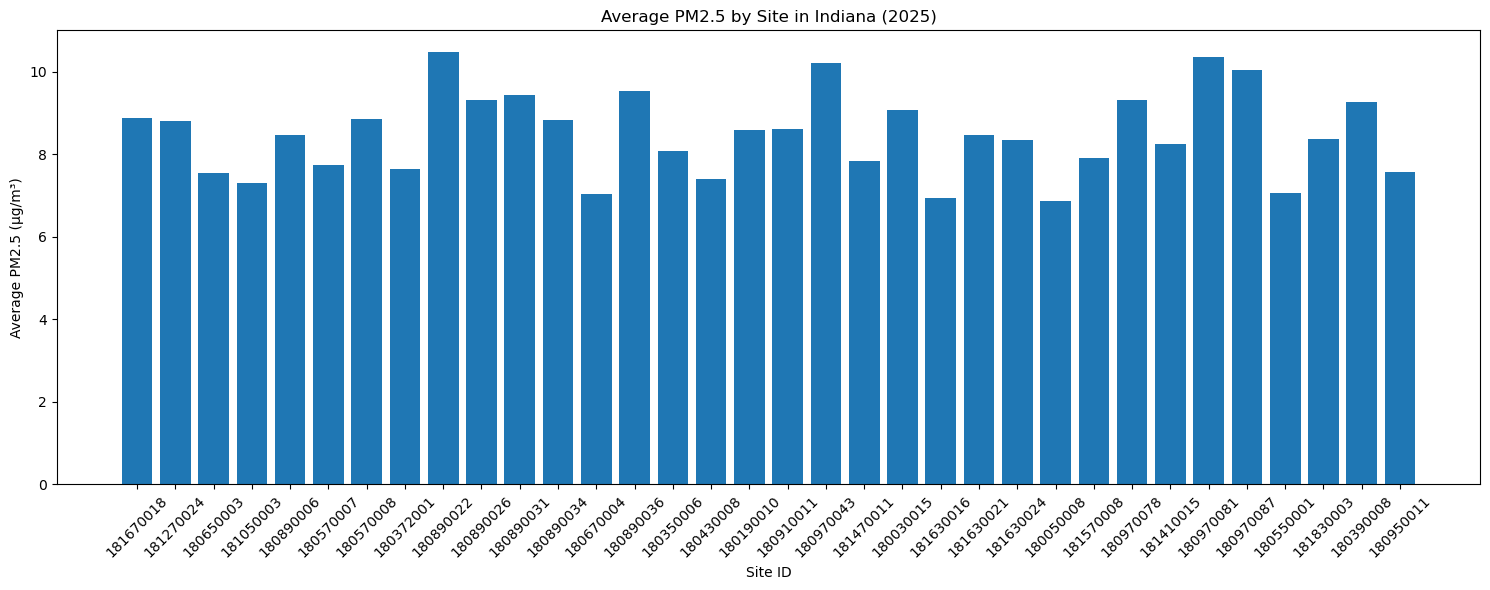


=== SELECTED SITE COMPARISON ===

Site 180190010:
    Avg:     8.59
    Std:     4.25
    Max:     27.5 (date 2025-07-05)
    Min:     1.7 (date 2025-10-29)

Site 180650003:
    Avg:     7.55
    Std:     4.07
    Max:     32.9 (date 2025-08-01)
    Min:     1.7 (date 2025-10-22)

Site 180890022:
    Avg:     10.48
    Std:     8.94
    Max:     143.7 (date 2025-04-22)
    Min:     1.7 (date 2025-05-22)

Site 181410015:
    Avg:     8.25
    Std:     5.93
    Max:     46.2 (date 2025-07-31)
    Min:     0.6 (date 2025-11-27)

Site 181630021:
    Avg:     8.46
    Std:     4.08
    Max:     29.5 (date 2025-01-09)
    Min:     1.5 (date 2025-04-05)



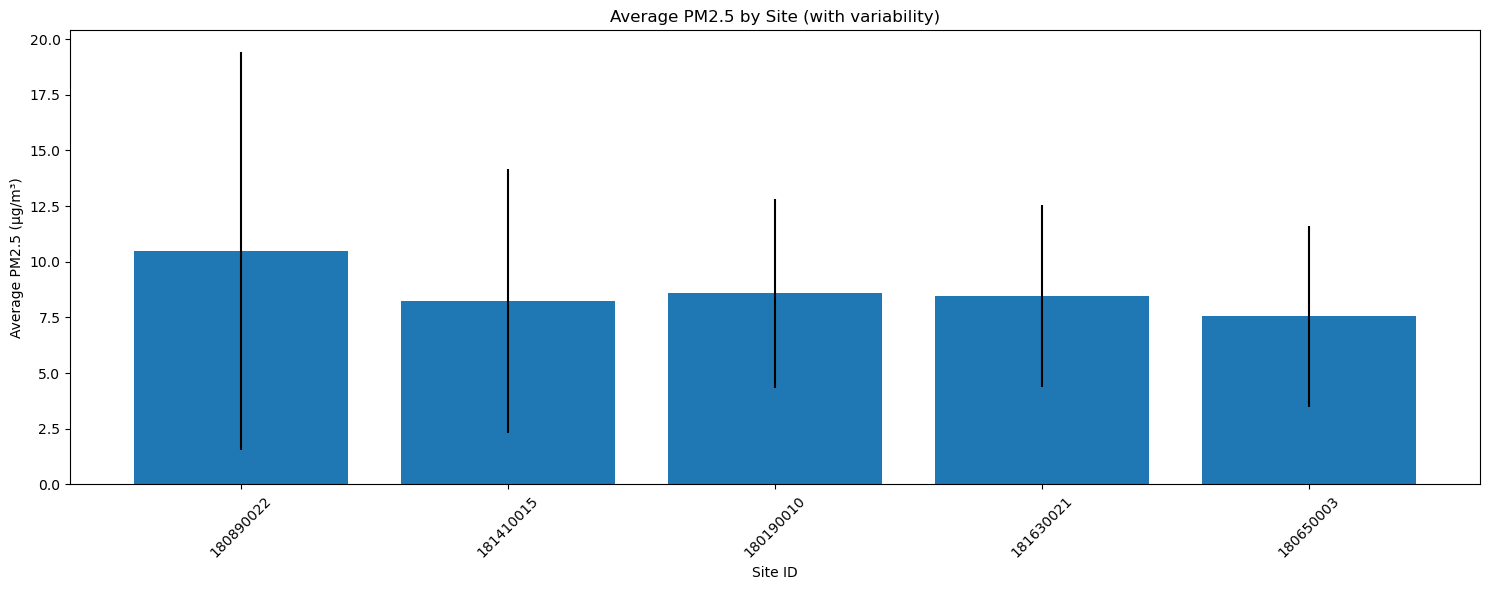

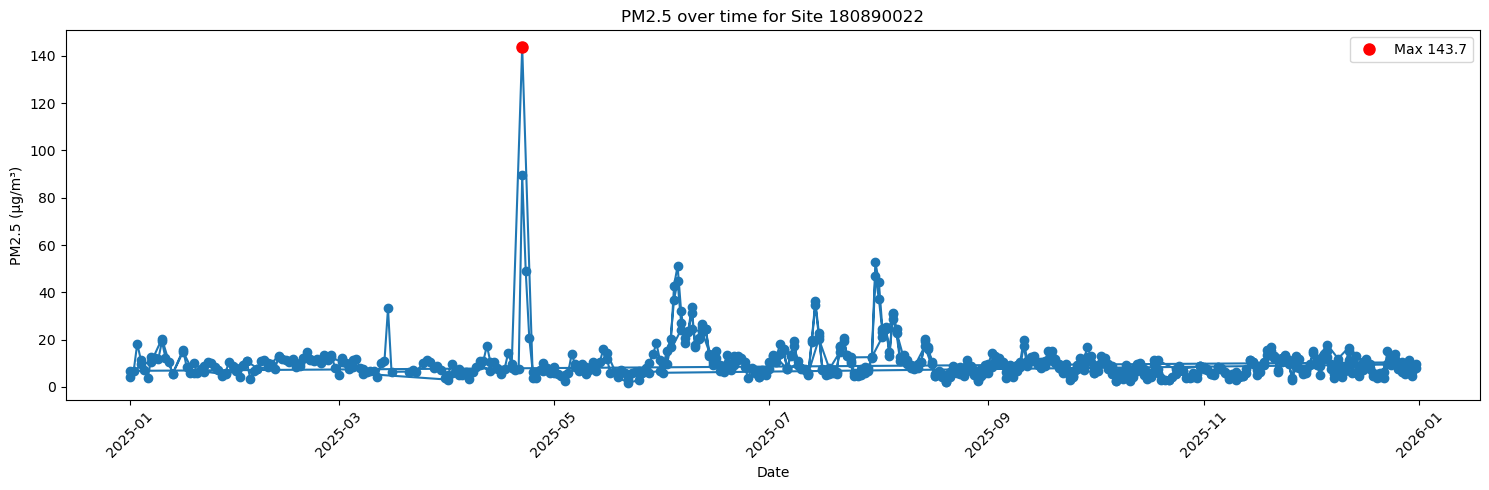

=== Extreme Anomalies ===
Site 180890022 | 2025-04-22 | 143.7
Site 180890022 | 2025-04-22 | 89.6
Site 180390008 | 2025-11-14 | 83.8
Site 180970081 | 2025-07-05 | 82.1
Site 180970078 | 2025-07-05 | 78.7
Site 180970087 | 2025-07-05 | 68.1
[0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0]
Accuracy: 1.0
[[2735    0]
 [   0   17]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2735
           1       1.00      1.00      1.00        17

    accuracy                           1.00      2752
   macro avg       1.00      1.00      1.00      2752
weighted avg       1.00      1.00      1.00      2752



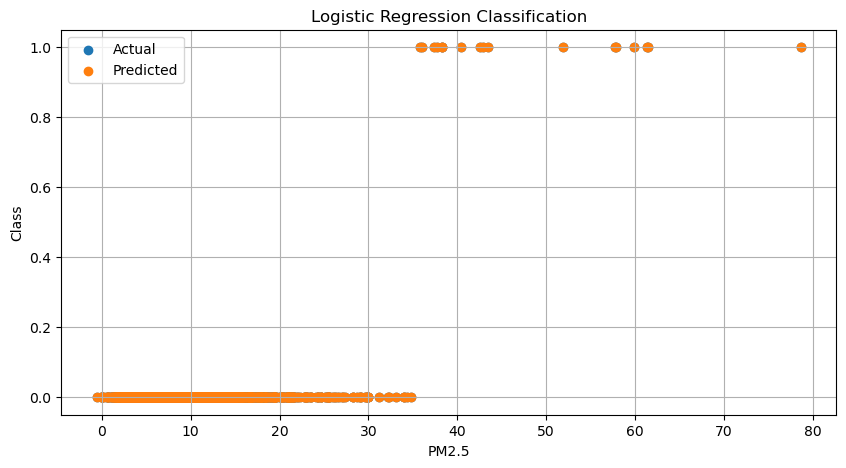

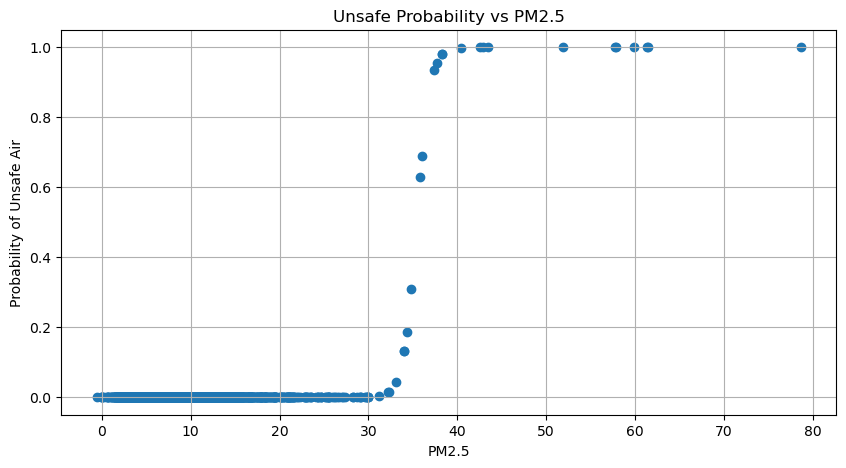

In [7]:
"""
PM2.5 Air Quality Analysis Pipeline
Indiana Air Quality Data (2025)

- Computes statistics per site
- Generates visualisations
- Detects extreme pollution events
- Exports results to JSON and CSV
"""

import csv
import math
import logging
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import json
import csv
import logging

#Logging setup
logging.basicConfig(     
    level=logging.INFO,  
    format='%(asctime)s - %(levelname)s - %(message)s',
    filename='air_quality_analysis.log',  
    filemode='a' 
)

def load_csv_pandas(filename):
    """ Load air quality CSV with pandas, clean it."""

    # Load and clean data
    df = pd.read_csv(filename)

    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')     #Cleans the data (deals with invalid cells)
    df['Site_ID'] = pd.to_numeric(df['Site ID'], errors='coerce')
    df['PM2.5'] = pd.to_numeric(df['Daily Mean PM2.5 Concentration'], errors='coerce')   #errors='coerce' converts invalid values → NaN (pandas version of None)

    df = df[['Date', 'Site_ID', 'PM2.5']]  #Select relevant columns
    
    valid_df = df.dropna(subset=['Date', 'Site_ID', 'PM2.5']).copy()  #Only keep rows where values are valid

    return valid_df

def compute_average_pm25(records):
    """Calculates the average PM2.5 level from a list of records."""
    total = 0
    count = 0

    for record in records:
        value = record['PM2.5']
        if value is not None:
            total += value
            count += 1

    if count == 0:
        logging.warning("No valid data for PM2.5 when computing average.")
        return None

    average = total / count
    return average

def compute_std_pm25(records):
    """Compute sample standard deviation of PM2.5 from a list of records."""
    
    clean_values = []
    
    for record in records:
        value = record['PM2.5']
        if value is not None:
            clean_values.append(value)

    n = len(clean_values)
    if n < 2:
        logging.warning("Not enough valid data to compute standard deviation.")
        return None

    mean = sum(clean_values) / n
    variance = sum((x - mean) ** 2 for x in clean_values) / (n - 1)  # sample SD

    return math.sqrt(variance)

def find_max_pm25(records):
    """Calculates the maxiumum PM 2.5 measurement."""
    if len(records) == 0:     
        return None

    max_record = None

    for record in records:
        value = record['PM2.5']

        if value is None:
            continue

        if max_record is None or value > max_record['PM2.5']:
            max_record = record

    return max_record    

def find_min_pm25(records):
    """Calculates the minimum PM 2.5 measurement."""
    if len(records) == 0:     
        return None

    min_record = None

    for record in records:
        value = record['PM2.5']

        if value is None:
            continue

        if min_record is None or value < min_record['PM2.5']:
            min_record = record

    return min_record    

def detect_anomalies(records):
    """Return records with statistically extreme PM2.5 anomalies."""
    
    pm25_anomalies = []

    for record in records:
        if record['PM2.5'] is not None:
            pm25_anomalies.append(record['PM2.5'])     

    mean = compute_average_pm25(records)
    std = compute_std_pm25(records)

    if mean is None or std is None:
        logging.warning("Cannot compute anomalies due to insufficient data.")
        return []

    extreme_records = []    

    for record in records:
        value = record['PM2.5']

        if value is None:
            continue

        if abs(value - mean) > 2 * std:    
            extreme_records.append(record)    

    logging.info(f"Detected {len(extreme_records)} extreme measurements")   

    return extreme_records

def get_unique_values(records): 
    """Gives you the group keys (Individual Site ID numbers)"""
    values = set()                      
    for record in records:
        values.add(record['Site_ID'])
    return values

def filter_by_field(records, field_name, value):
    """Filters the dataset by field name (eg 'Site_ID')"""
        
    filtered = []                        
    for record in records:                 
        if record[field_name] == value:    
            filtered.append(record)
    return filtered

def analyze_pm25(site_records):
    """Calls all the calculation functions."""

    if len(site_records) == 0:
        return None

    avg = compute_average_pm25(site_records)
    std = compute_std_pm25(site_records)
    max_rec = find_max_pm25(site_records)
    min_rec = find_min_pm25(site_records)

    # Prepare tidy dictionaries for max/min
    if max_rec is not None:
        max_data = {"value": max_rec['PM2.5'], "date": max_rec['Date']}
    else:
        max_data = None

    if min_rec is not None:
        min_data = {"value": min_rec['PM2.5'], "date": min_rec['Date']}
    else:
        min_data = None

    return {
        "average": avg,
        "std": std,
        "max": max_data,
        "min": min_data
    }
        
def build_master_results(records):
    """Builds a master dictionary with PM2.5 stats for each site."""
    
    master_results = {}

    site_ids = get_unique_values(records)

    for site_id in site_ids:
        site_records = filter_by_field(records, 'Site_ID', site_id)
        
        stats = analyze_pm25(site_records)
        master_results[site_id] = stats

    return master_results

def plot_pm25_averages(site_ids, averages):
    plt.figure(figsize=(15, 6))   # Width 15 inches, height 6 inches

    # Convert Site_IDs to strings so matplotlib treats them as categorical labels
    site_labels = [str(s) for s in site_ids]
    plt.bar(site_labels, averages)  # Plots Bar chart
   
    plt.xlabel("Site ID")
    plt.ylabel("Average PM2.5 (µg/m³)")
    plt.title("Average PM2.5 by Site in Indiana (2025)")
    plt.xticks(rotation=45)       #Rotate site IDs axis labels
    plt.tight_layout()  # Adjusts spacing so labels aren’t cut off
    plt.savefig("plot_pm25_averages.png")                #Saves the graph
    plt.show()

def plot_pm25_averages_with_std(site_ids, averages, stds):
    plt.figure(figsize=(15, 6))   # Width 15 inches, height 6 inches

    # Convert Site_IDs to strings so matplotlib treats them as categorical labels
    site_labels = [str(s) for s in site_ids]
    plt.bar(site_labels, averages, yerr=stds)  # Plots Bar chart
   
    plt.xlabel("Site ID")
    plt.ylabel("Average PM2.5 (µg/m³)")
    plt.title("Average PM2.5 by Site (with variability)")
    plt.xticks(rotation=45)       #Rotate site IDs axis labels
    plt.tight_layout()  # Adjusts spacing so labels aren’t cut off
    plt.savefig("plot_pm25_averages_with_std.png")                #Saves the graph
    plt.show()

def extract_pm25_timeseries(site_data, site_id):
    """Return lists of dates and PM2.5 values for a given site."""
    dates = []
    values = []
    
    for record in site_data[site_id]:
        dates.append(record['Date'])
        values.append(record['PM2.5'])
        
    return dates, values
    
def plot_pm25_over_time(dates, values, site_id=None, highlight_max=True):
    plt.figure(figsize=(15, 5))
    plt.plot(dates, values, marker='o', linestyle='-', color='tab:blue')

    if highlight_max:
        max_value = max(values)
        max_index = values.index(max_value)
        plt.plot(dates[max_index], max_value, 'ro', markersize=8, label=f'Max {max_value}')
        plt.legend()
        
    plt.xlabel("Date")
    plt.ylabel("PM2.5 (µg/m³)")
    title = f"PM2.5 over time for Site {site_id}" if site_id else "PM2.5 over time"
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("plot_pm25_over_time.png")
    plt.show()

def detect_global_anomalies(records):
    """Return records with statistically VERY extreme PM2.5 anomalies."""
    
    mean = compute_average_pm25(records)
    std = compute_std_pm25(records)

    if mean is None or std is None:
        logging.warning("Cannot compute anomalies due to insufficient data.")
        return []

    extreme_records = []    

    for record in records:
        value = record['PM2.5']

        if value is None:
            continue

        if value > mean + 10 * std:
            extreme_records.append(record)    

    logging.info(f"Detected {len(extreme_records)} extreme measurements")   

    return extreme_records

def print_report(master_results):
    """Prints statistics by site (from master_results)"""
    
    if master_results is None:
        print("No results available. Run analysis first.")
        return

    for site in sorted(master_results):  #sorted() orders the sites numerically
        print(f"Site {site}:")
        
        stats = master_results[site]
       
        avg_value = stats['average']
        std_value = stats['std']
        max_record = stats['max']
        min_record = stats['min']

        if avg_value is not None:
            print(f"    Avg:     {avg_value:.2f}") 
        else:
            print("    Avg: No valid data")

        if std_value is not None:
            print(f"    Std:     {std_value:.2f}") 
        else:
            print("    Std: No valid data")

        if max_record is not None:
            print(f"    Max:     {max_record['value']} (date {max_record['date'].strftime('%Y-%m-%d')})")
        else:
            print("    Max: No valid data")

        if min_record is not None:
            print(f"    Min:     {min_record['value']} (date {min_record['date'].strftime('%Y-%m-%d')})")
        else:
            print("    Min: No valid data")

        print()  # blank line between sites

def save_to_json(master_results, filename="pm25_results.json"):
    json_ready_results = {}

    #Convert datetime in 'date' to a JSON readable format
    for site in master_results:
        stats = master_results[site]

        json_ready_results[site] = {
            "average": stats['average'],
            "std": stats['std'],
            "max": {
                "value": stats['max']['value'],
                "date": stats['max']['date'].strftime('%Y-%m-%d')
            } if stats['max'] is not None else None,
            
            "min": {
                "value": stats['min']['value'],
                "date": stats['min']['date'].strftime('%Y-%m-%d')
            } if stats['min'] is not None else None
        }

    with open(filename, 'w') as f:
        json.dump(json_ready_results, f, indent=4)

def save_to_csv(master_results, filename="pm25_results.csv"):
    with open(filename, 'w', newline='') as f:
        writer = csv.writer(f)
        
        # Header row
        writer.writerow([
            "Site_ID", "Average", "Std",
            "Max_Value", "Max_Date",
            "Min_Value", "Min_Date"
        ])
        
        for site in master_results:
            stats = master_results[site]
            
            max_value = stats['max']['value'] if stats['max'] else None
            max_date = stats['max']['date'].strftime('%Y-%m-%d') if stats['max'] else None
            
            min_value = stats['min']['value'] if stats['min'] else None
            min_date = stats['min']['date'].strftime('%Y-%m-%d') if stats['min'] else None
            
            writer.writerow([
                site,
                stats['average'],
                stats['std'],
                max_value,
                max_date,
                min_value,
                min_date
            ])

def save_anomalies_to_json(anomalies, filename="air_quality_anomalies.json"):
    cleaned = []
    
    for record in anomalies:
        cleaned.append({
            "Site_ID": record['Site_ID'],
            "Date": record['Date'].strftime('%Y-%m-%d'),
            "PM2.5": record['PM2.5']
        })
    
    with open(filename, 'w') as f:
        json.dump(cleaned, f, indent=4)

def classify_pm25(value):
    if value is None:
        return None

    if value <= 35:
        return 0
    else:
        return 1

def extract_classification_dataset(records):
    """Extract values to use in NumPy functions"""
    X = []
    y = []

    for record in records:
        
        pm25 = record["PM2.5"]

        if pm25 is None:
            continue

        X.append(pm25)
        y.append(classify_pm25(pm25))

    return X, y




# =========================
# CONTROL PANEL
# =========================

# 1. Load and prepare data
logging.info("Loading data from CSV")

try:
    valid_df = load_csv_pandas("epa_data_indiana_2025.csv")   #Extract valid_df (DataFrame Table) for use with pandas code
    records = valid_df.to_dict(orient='records')              #Extract list of dictionaries (each row) for use with pure python code
    logging.info("Data successfully loaded")
except Exception as e:
    logging.error(f"Failed to load data: {e}")
    
# 2. Build master results (all sites)
logging.info("Building master results")

try:
    master_results = build_master_results(records)
    logging.info("Data successfully analysed")
except Exception as e:
    logging.error(f"Analysis failed: {e}")

# 3. Print summary report
logging.info("Printing reports and generating plots")
print("\n=== FULL DATASET REPORT ===\n")
print_report(master_results)

# 4. Plot overall averages (all sites)
site_ids = []
averages = []

for site in master_results:
    avg_value = master_results[site]['average']
    if avg_value is not None:
        site_ids.append(site)
        averages.append(avg_value)

plot_pm25_averages(site_ids, averages)

# 5. Compare selected sites
selected_sites = [180890022, 181410015, 180190010, 181630021, 180650003]

site_data = {}
for site_id in selected_sites:
    site_data[site_id] = filter_by_field(records, 'Site_ID', site_id)

comparison_results = {}
for site_id in site_data:
    comparison_results[site_id] = analyze_pm25(site_data[site_id])

# 6. Plot comparison (with std)
comp_site_ids = []
comp_averages = []
comp_stds = []

for site in comparison_results:
    stats = comparison_results[site]
    if stats['average'] is not None and stats['std'] is not None:
        comp_site_ids.append(site)
        comp_averages.append(stats['average'])
        comp_stds.append(stats['std'])

print("\n=== SELECTED SITE COMPARISON ===\n")
print_report(comparison_results)

plot_pm25_averages_with_std(comp_site_ids, comp_averages, comp_stds)

#Specific line plot for site 180890022 (can be used for any site) to investigate anomaly
dates, values = extract_pm25_timeseries(site_data, 180890022)
plot_pm25_over_time(dates, values, site_id=180890022)

# 7. Detect extreme anomalies
print("=== Extreme Anomalies ===")
anomalies = detect_global_anomalies(records)
anomalies_sorted = sorted(anomalies, key=lambda r: r['PM2.5'], reverse=True)

for record in anomalies_sorted:
    print(f"Site {record['Site_ID']} | {record['Date'].strftime('%Y-%m-%d')} | {record['PM2.5']}")

save_anomalies_to_json(anomalies)

logging.info(f"Detected {len(anomalies)} extreme anomalies")
logging.info("Reports and graphs generated")

# 8. Save to JSOn and CSV files
logging.info("Saving results")

try:
    save_to_json(master_results)
    save_to_csv(master_results)
    logging.info("Results successfully saved to JSON and CSV")
except Exception as e:
    logging.error(f"Saving failed: {e}")

X, y = extract_classification_dataset(records)

X = np.array(X)
y = np.array(y)

X = X.reshape(-1, 1)   

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_pred[:10])
print(y_test[:10])

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)

print(cm)

print(classification_report(y_test, y_pred))

plt.figure(figsize=(10,5))

plt.scatter(X_test, y_test, label="Actual")
plt.scatter(X_test, y_pred, label="Predicted")

plt.xlabel("PM2.5")
plt.ylabel("Class")
plt.title("Logistic Regression Classification")

plt.legend()
plt.grid(True)
plt.savefig("logistic_regression_classification.png")    

plt.show()

probabilities = model.predict_proba(X_test)

unsafe_probabilities = probabilities[:, 1]   #Selects column 1, probability of unsafe class

plt.figure(figsize=(10,5))

plt.scatter(X_test, unsafe_probabilities)

plt.xlabel("PM2.5")
plt.ylabel("Probability of Unsafe Air")
plt.title("Unsafe Probability vs PM2.5")

plt.grid(True)
plt.savefig("unsafe_probablilty_vs_pm25.png")  

plt.show()